In [22]:
import matplotlib.pyplot as plt
from sklearn import discriminant_analysis, naive_bayes, metrics
from sklearn import linear_model, svm, tree, neighbors, dummy
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score

Oblik (8, 8)


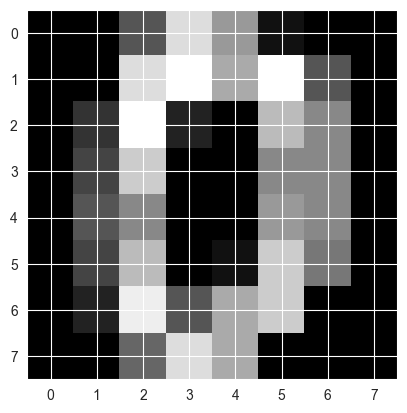

In [23]:
digits = datasets.load_digits()
print("Oblik", digits.images[0].shape)
plt.Figure(figsize=(3, 3))
plt.imshow(digits.images[0], cmap='gray')

In [24]:
classifiers = {
    'LogReg(1)': linear_model.LogisticRegression(max_iter=1000),
    'LogReg(2)': linear_model.SGDClassifier(max_iter=1000),
    'QDA': discriminant_analysis.QuadraticDiscriminantAnalysis(),
    'LDA': discriminant_analysis.LinearDiscriminantAnalysis(),
    'GNB': naive_bayes.GaussianNB(),
    'SVC(1)': svm.SVC(kernel='linear'),
    'SVC(2)': svm.LinearSVC(),
    'DTC': tree.DecisionTreeClassifier(),
    '5NN-C': neighbors.KNeighborsClassifier(),
    '10NN-C': neighbors.KNeighborsClassifier(n_neighbors=10)
}

baseline = dummy.DummyClassifier(strategy='uniform')
base_score = cross_val_score(baseline, digits.images, digits.target==1, cv=10, scoring='average_precision')

/Users/davorin-ai/workspace/education-ai/ai-centar-lipik/.venv/lib/python3.13/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Users/davorin-ai/workspace/education-ai/ai-centar-lipik/.venv/lib/python3.13/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Users/davorin-ai/workspace/education-ai/ai-centar-lipik/.venv/lib/python3.13/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Users/davorin-ai/workspace/education-ai/ai-centar-lipik/.venv/lib/python3.13/site-packages/sklearn/discri

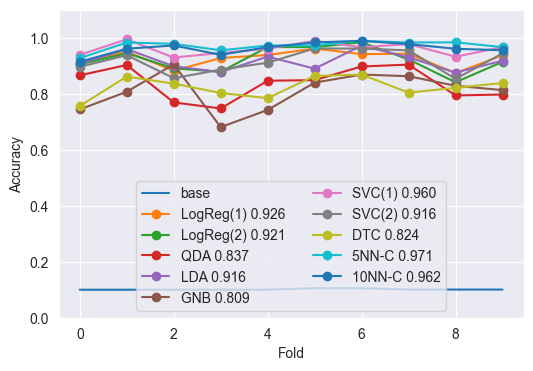

In [25]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(base_score, label='base')
markers = ['o']
for name, model in classifiers.items():
    cv_scores = cross_val_score(model, digits.data, digits.target, cv=10, scoring='f1_macro', n_jobs=-1) # all CPUs
    my_lbl = "{} {:.3f}".format(name, cv_scores.mean())
    ax.plot(cv_scores, label=my_lbl, marker=next(iter(markers))) # Use iter(markers) to cycle through markers
ax.set_ylim(0.0, 1.1)
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.legend(loc='lower center', ncol=2)